# ⭐ Actividad 07 — Data Warehouse: Star Schema v2.0
---
## Modelo Dimensional Puro — `limon_analytics_db`

**Arquitectura Star Schema con 5 Dimensiones Satélite**

```
                         ┌─────────────────────┐
                         │     dim_tiempo       │
                         │ id_tiempo (PK)       │
                         │ fecha_evento, anho   │
                         │ month_sin, month_cos │
                         └──────────┬──────────┘
                                    │ FK
  ┌────────────────┐      ┌─────────▼──────────────┐      ┌────────────────────┐
  │  dim_ubicacion │      │  fact_produccion_limon ★│      │   dim_emergencia   │
  │ id_ubicacion(PK)◄────►│ id_hecho (PK)          │◄────►│ id_emergencia (PK) │
  │ departamento   │      │ id_tiempo (FK)          │      │ tipo_emergencia     │
  │ provincia      │      │ id_ubicacion (FK)       │      │ gravedad           │
  │ distrito       │      │ id_clima (FK)           │      └────────────────────┘
  │ lat, lon       │      │ id_emergencia (FK)      │
  └────────────────┘      │ id_noticias (FK)        │      ┌────────────────────┐
                          │ --- Métricas MIDAGRI ---│      │    dim_noticias     │
                          │ produccion_t FLOAT      │◄────►│ id_noticias (PK)   │
                          │ cosecha_ha FLOAT        │      │ avg_sentimiento    │
                          │ precio_chacra_kg FLOAT  │      │ n_noticias         │
                          └─────────┬──────────────┘      └────────────────────┘
                                    │ FK
                         ┌──────────▼──────────┐
                         │      dim_clima       │
                         │ id_clima (PK)        │
                         │ temp_max_c, temp_min │
                         │ precipitacion_mm     │
                         │ is_extreme_weather   │
                         └─────────────────────┘
```

| Aspecto | Decisión |
|:--------|:---------|
| **Tipo** | Star Schema Puro — 5 dimensiones, JOINs simples para OLAP |
| **Granularidad** | Mensual × Provincia × Distrito |
| **fact_produccion_limon** | Solo FKs + métricas de producción MIDAGRI |
| **dim_clima** | Encapsula toda la data NASA POWER |
| **dim_emergencia** | Encapsula toda la data INDECI SINPAD |
| **dim_noticias** | Encapsula sentimiento NLP + conteo Agraria.pe |
| **Sentimiento** | avg_sentimiento en dim_noticias (Fase 2: BETO) |


In [1]:
%matplotlib inline
import os, sys, json, re, warnings, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; REPORTS=DIRS['reports']; PROCESSED=DIRS['processed']
print(f"✅ Setup OK | {os.getcwd()}")

✅ Setup OK | C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 7.1 Visualización del Diagrama con Matplotlib (Star Schema v2.0)

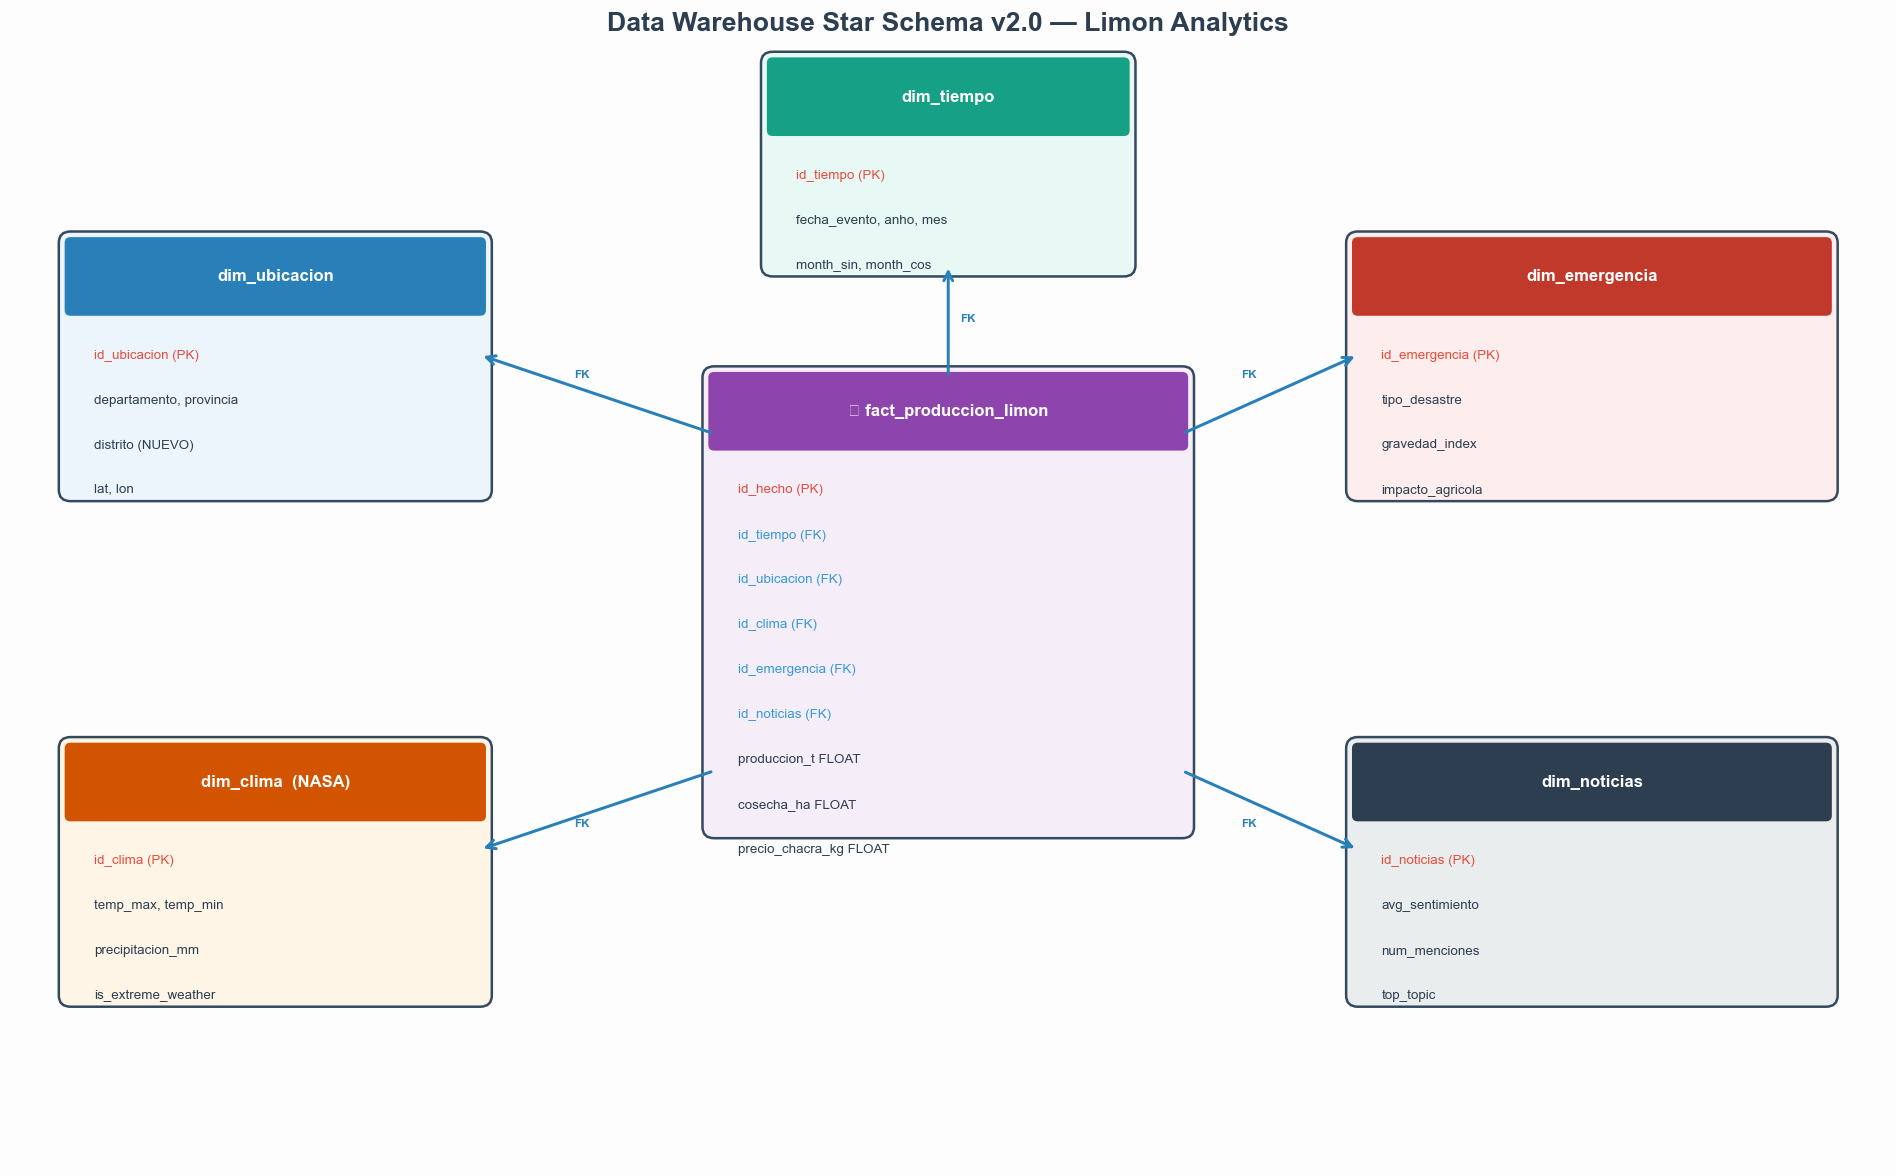

Diagrama Star Schema v2.0 (5 dimensiones) generado


In [2]:

import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('#fdfdfd')

def draw_table(ax, x, y, w, h, title, rows, color_h='#2c3e50', color_b='#ffffff'):
    ax.add_patch(mpatches.FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.1",
        facecolor=color_b, edgecolor='#34495e', linewidth=1.5))
    ax.add_patch(mpatches.FancyBboxPatch((x,y+h-0.6), w, 0.6, boxstyle="round,pad=0.05",
        facecolor=color_h, edgecolor='none'))
    ax.text(x+w/2, y+h-0.3, title, ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    for i, (row, clr) in enumerate(rows):
        color = '#e74c3c' if clr=='k' else '#3498db' if clr=='f' else '#2c3e50'
        ax.text(x+0.2, y+h-1.0-i*0.4, row, va='center', fontsize=8, color=color)

# --- TABLA CENTRAL: HECHOS ---
draw_table(ax, 6, 3, 4, 4, '★ fact_produccion_limon', [
    ('id_hecho (PK)', 'k'), ('id_tiempo (FK)', 'f'), ('id_ubicacion (FK)', 'f'),
    ('id_clima (FK)', 'f'), ('id_emergencia (FK)', 'f'), ('id_noticias (FK)', 'f'),
    ('produccion_t FLOAT', 'n'), ('cosecha_ha FLOAT', 'n'), ('precio_chacra_kg FLOAT', 'n')
], '#8e44ad', '#f5eef8')

# --- 5 DIMENSIONES EN CIRCULO ---
# Arriba: dim_tiempo
draw_table(ax, 6.5, 8, 3, 1.8, 'dim_tiempo', [
    ('id_tiempo (PK)', 'k'), ('fecha_evento, anho, mes', 'n'), ('month_sin, month_cos', 'n')
], '#16a085', '#e8f8f5')

# Izquierda: dim_ubicacion
draw_table(ax, 0.5, 6, 3.5, 2.2, 'dim_ubicacion', [
    ('id_ubicacion (PK)', 'k'), ('departamento, provincia', 'n'), ('distrito (NUEVO)', 'n'), ('lat, lon', 'n')
], '#2980b9', '#ebf5fb')

# Abajo-izquierda: dim_clima
draw_table(ax, 0.5, 1.5, 3.5, 2.2, 'dim_clima  (NASA)', [
    ('id_clima (PK)', 'k'), ('temp_max, temp_min', 'n'), ('precipitacion_mm', 'n'), ('is_extreme_weather', 'n')
], '#d35400', '#fef5e7')

# Derecha: dim_emergencia
draw_table(ax, 11.5, 6, 4, 2.2, 'dim_emergencia', [
    ('id_emergencia (PK)', 'k'), ('tipo_desastre', 'n'), ('gravedad_index', 'n'), ('impacto_agricola', 'n')
], '#c0392b', '#fdedec')

# Abajo-derecha: dim_noticias
draw_table(ax, 11.5, 1.5, 4, 2.2, 'dim_noticias', [
    ('id_noticias (PK)', 'k'), ('avg_sentimiento', 'n'), ('num_menciones', 'n'), ('top_topic', 'n')
], '#2c3e50', '#eaeded')

# --- FLECHAS FK ---
arrow_kw = dict(arrowstyle='->', color='#2980b9', lw=1.8,
                connectionstyle='arc3,rad=0.0')
# fact -> dim_tiempo
ax.annotate('', xy=(8, 8.0), xytext=(8, 7.0), arrowprops=arrow_kw)
ax.text(8.1, 7.5, 'FK', fontsize=7, color='#2980b9', fontweight='bold')
# fact -> dim_ubicacion
ax.annotate('', xy=(4.0, 7.2), xytext=(6.0, 6.5), arrowprops=arrow_kw)
ax.text(4.8, 7.0, 'FK', fontsize=7, color='#2980b9', fontweight='bold')
# fact -> dim_clima
ax.annotate('', xy=(4.0, 2.8), xytext=(6.0, 3.5), arrowprops=arrow_kw)
ax.text(4.8, 3.0, 'FK', fontsize=7, color='#2980b9', fontweight='bold')
# fact -> dim_emergencia
ax.annotate('', xy=(11.5, 7.2), xytext=(10.0, 6.5), arrowprops=arrow_kw)
ax.text(10.5, 7.0, 'FK', fontsize=7, color='#2980b9', fontweight='bold')
# fact -> dim_noticias
ax.annotate('', xy=(11.5, 2.8), xytext=(10.0, 3.5), arrowprops=arrow_kw)
ax.text(10.5, 3.0, 'FK', fontsize=7, color='#2980b9', fontweight='bold')

plt.title("Data Warehouse Star Schema v2.0 — Limon Analytics", fontsize=16, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.savefig(f"{REPORTS}/g07_star_schema_v2.png", dpi=150, bbox_inches='tight')
plt.show()
print("Diagrama Star Schema v2.0 (5 dimensiones) generado")


## 7.2 DDL del Star Schema v2.0 (5 Dimensiones Puras)

In [3]:

DDL = '''
-- =============================================
-- STAR SCHEMA v2.0 — limon_analytics_db
-- Proyecto: Prediccion de Produccion de Limon
-- 5 Dimensiones Puras + 1 Tabla de Hechos
-- =============================================

-- 1. Dimensiones secundarias (sin FKs propias)
CREATE TABLE IF NOT EXISTS dim_clima (
    id_clima SERIAL PRIMARY KEY,
    temp_max_c FLOAT, temp_min_c FLOAT, precipitacion_mm FLOAT,
    humedad_rel_pct FLOAT, velocidad_viento FLOAT, radiacion_solar FLOAT,
    is_extreme_weather BOOLEAN DEFAULT FALSE
);

CREATE TABLE IF NOT EXISTS dim_emergencia (
    id_emergencia SERIAL PRIMARY KEY,
    tipo_emergencia VARCHAR(100),
    num_emergencias INT DEFAULT 0,
    total_afectados INT DEFAULT 0,
    has_cultivo_perdidas FLOAT DEFAULT 0,
    gravedad SMALLINT
);

CREATE TABLE IF NOT EXISTS dim_noticias (
    id_noticias SERIAL PRIMARY KEY,
    avg_sentimiento FLOAT,
    n_noticias INT DEFAULT 0,
    tema_principal VARCHAR(100)
);

-- 2. Dimensiones base
CREATE TABLE IF NOT EXISTS dim_tiempo (
    id_tiempo SERIAL PRIMARY KEY,
    fecha_evento VARCHAR(7) NOT NULL UNIQUE,
    anho SMALLINT NOT NULL, mes SMALLINT NOT NULL,
    trimestre SMALLINT,
    month_sin FLOAT, month_cos FLOAT
);

CREATE TABLE IF NOT EXISTS dim_ubicacion (
    id_ubicacion SERIAL PRIMARY KEY,
    departamento VARCHAR(60) NOT NULL,
    provincia VARCHAR(60) NOT NULL,
    distrito VARCHAR(80),
    lat FLOAT, lon FLOAT,
    UNIQUE(departamento, provincia)
);

-- 3. Tabla de Hechos LIMPIA (solo FKs + metricas produccion)
CREATE TABLE IF NOT EXISTS fact_produccion_limon (
    id_hecho SERIAL PRIMARY KEY,
    id_tiempo INT REFERENCES dim_tiempo(id_tiempo),
    id_ubicacion INT REFERENCES dim_ubicacion(id_ubicacion),
    id_clima INT REFERENCES dim_clima(id_clima),
    id_emergencia INT REFERENCES dim_emergencia(id_emergencia),
    id_noticias INT REFERENCES dim_noticias(id_noticias),
    -- Metricas MIDAGRI (unicas metricas en la tabla de hechos)
    produccion_t FLOAT DEFAULT 0,
    cosecha_ha FLOAT DEFAULT 0,
    precio_chacra_kg FLOAT,
    UNIQUE(id_tiempo, id_ubicacion)
);

-- Indices
CREATE INDEX IF NOT EXISTS idx_fact_tiempo ON fact_produccion_limon(id_tiempo);
CREATE INDEX IF NOT EXISTS idx_fact_ubicacion ON fact_produccion_limon(id_ubicacion);
CREATE INDEX IF NOT EXISTS idx_fact_clima ON fact_produccion_limon(id_clima);
'''
import os
sql_path = f"{DIRS['database']}/dwh_star_schema_v2.sql"
with open(sql_path, 'w', encoding='utf-8') as f: f.write(DDL)
print(DDL)
print(f"[OK] {sql_path}")
print("[ACTIVIDAD 07] COMPLETADA - Star Schema v2.0 con 5 dimensiones puras")



-- =============================================
-- STAR SCHEMA v2.0 — limon_analytics_db
-- Proyecto: Prediccion de Produccion de Limon
-- 5 Dimensiones Puras + 1 Tabla de Hechos
-- =============================================

-- 1. Dimensiones secundarias (sin FKs propias)
CREATE TABLE IF NOT EXISTS dim_clima (
    id_clima SERIAL PRIMARY KEY,
    temp_max_c FLOAT, temp_min_c FLOAT, precipitacion_mm FLOAT,
    humedad_rel_pct FLOAT, velocidad_viento FLOAT, radiacion_solar FLOAT,
    is_extreme_weather BOOLEAN DEFAULT FALSE
);

CREATE TABLE IF NOT EXISTS dim_emergencia (
    id_emergencia SERIAL PRIMARY KEY,
    tipo_emergencia VARCHAR(100),
    num_emergencias INT DEFAULT 0,
    total_afectados INT DEFAULT 0,
    has_cultivo_perdidas FLOAT DEFAULT 0,
    gravedad SMALLINT
);

CREATE TABLE IF NOT EXISTS dim_noticias (
    id_noticias SERIAL PRIMARY KEY,
    avg_sentimiento FLOAT,
    n_noticias INT DEFAULT 0,
    tema_principal VARCHAR(100)
);

-- 2. Dimensiones base
CREATE TABLE I

## 7.3 Arquitectura Star Schema v2.0 — Decisión de Diseño

En el **Star Schema v2.0**, los datos de la NASA POWER se encapsulan en **`dim_clima`**, una dimensión satélite dedicada. Esto sigue las mejores prácticas de Data Warehousing:

| Decisión | Justificación |
|:---------|:-------------|
| `dim_clima` separada | Agrupa coherentemente las 6 variables climáticas NASA |
| `dim_emergencia` separada | Desacopla los datos INDECI de la tabla de hechos |
| `dim_noticias` separada | Permite escalar el módulo NLP en Fase 2 sin alterar la fact |
| `fact` solo con 3 métricas | Principio de tabla de hechos limpia: solo FKs + métricas de producción |